<a href="https://colab.research.google.com/github/arif-sudaryanto/ai-fuzzy-harga-paket-penjualan-pv/blob/main/02_Fuzzy_Penjualan_PV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fuzzy Inference - Harga Paket Penjualan PV
---

Tugas Mata Kuliah Kecerdasan Buatan (X)

Nama : Arif Sudaryanto

Nrp.  : 6022251007

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def trap_mf(x, a, b, c, d):
    return np.maximum(0, np.minimum(np.minimum((x-a)/(b-a) if b > a else 1, 1), (d-x)/(d-c) if d > c else 1))

def tri_mf(x, a, b, c):
    return np.maximum(0, np.minimum((x-a)/(b-a) if b > a else 1, (c-x)/(c-b) if c > b else 1))

out_values = {
    'Basic': 15,
    'Premium': 35,
    'Platinum': 60
}

def calculate_price(area, power, verbose=False):
    # Fuzzifikasi Input 1
    mu_area = {
        'sedikit': trap_mf(area, 0, 0, 10, 20),
        'sedang': tri_mf(area, 10, 25, 40),
        'banyak': trap_mf(area, 30, 40, 50, 50)
    }

    # Fuzzifikasi Input 2
    mu_power = {
        'kecil': trap_mf(power, 0, 0, 2, 4),
        'menengah': tri_mf(power, 2, 5, 8),
        'besar': trap_mf(power, 6, 8, 10, 10)
    }

    # Rule Base[3x3]
    rules = [
        ('sedikit', 'kecil', 'Basic'),
        ('sedikit', 'menengah', 'Basic'),
        ('sedikit', 'besar', 'Premium'),
        ('sedang', 'kecil', 'Basic'),
        ('sedang', 'menengah', 'Premium'),
        ('sedang', 'besar', 'Platinum'),
        ('banyak', 'kecil', 'Premium'),
        ('banyak', 'menengah', 'Platinum'),
        ('banyak', 'besar', 'Platinum')
    ]

    # 4. Defuzzifikasi (WEIGHTED AVERAGE)
    num = 0
    den = 0

    if verbose:
        print(f"== Evaluasi Rulebase Fuzzy (Input: Area= {area}, Daya= {power}) ==")

    for r_area, r_power, out_class in rules:
        # Operasi AND menggunakan MIN
        w = min(mu_area[r_area], mu_power[r_power])

        if w > 0:
            z = out_values[out_class]
            num += w * z
            den += w

            if verbose:
                print(f"IF Area {r_area} AND Daya {r_power} THEN {out_class} | Bobot: {w:.2f}")

    if den == 0: return 0
    return num / den

# Visualisasi

In [20]:
def plot_membership(input_area, input_power):

    x_area = np.linspace(0,50,500)
    x_power = np.linspace(0,10,500)

    plt.figure(figsize=(14,3))

    # Area PV
    plt.subplot(1,2,1)

    plt.plot(x_area, trap_mf(x_area,0,0,10,20), label='Sedikit')
    plt.plot(x_area, tri_mf(x_area,10,25,40), label='Sedang')
    plt.plot(x_area, trap_mf(x_area,30,40,50,50), label='Banyak')

    plt.axvline(input_area, color='black', linestyle='--', label='Input Area')
    plt.scatter(input_area, 0, color='black')

    plt.title("Membership Function - Area PV")
    plt.xlabel("Area (m²)")
    plt.ylabel("Membership")
    plt.legend()
    plt.grid(True)

    # Pwer
    plt.subplot(1,2,2)

    plt.plot(x_power, trap_mf(x_power,0,0,2,4), label='Kecil')
    plt.plot(x_power, tri_mf(x_power,2,5,8), label='Menengah')
    plt.plot(x_power, trap_mf(x_power,6,8,10,10), label='Besar')

    plt.axvline(input_power, color='black', linestyle='--', label='Input Power')
    plt.scatter(input_power, 0, color='black')

    plt.title("Membership Function - Daya")
    plt.xlabel("Power (kWp)")
    plt.ylabel("Membership")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def plot_rule_activation(area, power):

    mu_area = {
        'sedikit': trap_mf(area,0,0,10,20),
        'sedang': tri_mf(area,10,25,40),
        'banyak': trap_mf(area,30,40,50,50)
    }

    mu_power = {
        'kecil': trap_mf(power,0,0,2,4),
        'menengah': tri_mf(power,2,5,8),
        'besar': trap_mf(power,6,8,10,10)
    }

    rules = [
        ('sedikit','kecil','Basic'),
        ('sedikit','menengah','Basic'),
        ('sedikit','besar','Premium'),
        ('sedang','kecil','Basic'),
        ('sedang','menengah','Premium'),
        ('sedang','besar','Platinum'),
        ('banyak','kecil','Premium'),
        ('banyak','menengah','Platinum'),
        ('banyak','besar','Platinum')
    ]

    names = []
    weights = []

    for r_area,r_power,out in rules:

        w = min(mu_area[r_area], mu_power[r_power])

        names.append(f"{r_area}-{r_power}")
        weights.append(w)

    plt.figure(figsize=(7,3))

    plt.bar(names, weights)

    plt.title("Rule Activation (Firing Strength)")
    plt.ylabel("Weight")
    plt.xlabel("RULE BASE")

    plt.xticks(rotation=90)

    plt.grid(True)

    plt.show()

from mpl_toolkits.mplot3d import Axes3D

def plot_surface():

    area_vals = np.linspace(0,50,50)
    power_vals = np.linspace(0,10,50)

    A, P = np.meshgrid(area_vals, power_vals)

    Z = np.zeros_like(A)

    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            Z[i,j] = calculate_price(A[i,j],P[i,j])

    fig = plt.figure(figsize=(12,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(A,P,Z,cmap='viridis')
    plt.subplots_adjust(left=0.05, right=0.85, bottom=0.1, top=0.9)

    ax.set_xlabel("Area PV")
    ax.set_ylabel("Power")
    ax.set_zlabel("Harga Paket", labelpad=15)

    plt.title("Fuzzy Surface Output")

    plt.show()

== Evaluasi Rulebase Fuzzy (Input: Area= 12, Daya= 7) ==
IF Area sedikit AND Daya menengah THEN Basic | Bobot: 0.33
IF Area sedikit AND Daya besar THEN Premium | Bobot: 0.50
IF Area sedang AND Daya menengah THEN Premium | Bobot: 0.13
IF Area sedang AND Daya besar THEN Platinum | Bobot: 0.13

Hasil Akhir Harga Paket: Rp 31.97 Juta


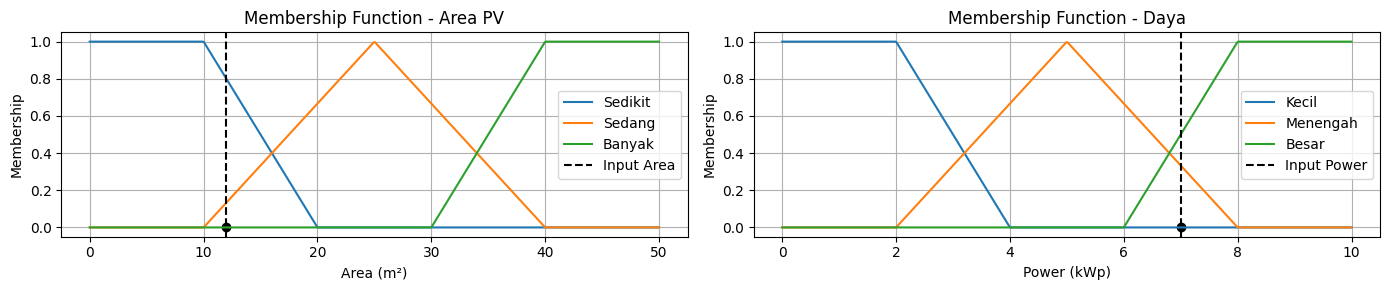

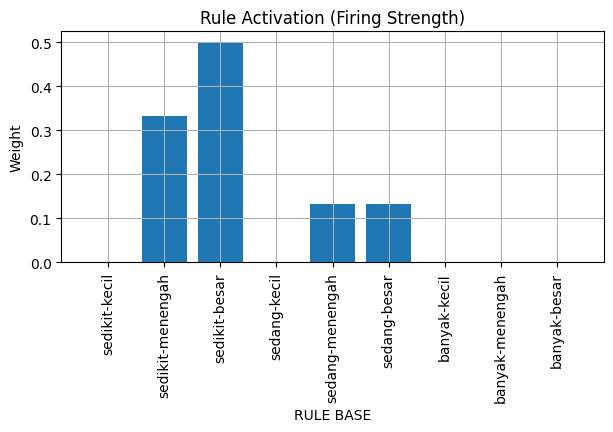

In [21]:
# Uji data
input_area = 12     # 0 s.d. 50
input_power = 7     # 0 s.d. 10

harga_paket = calculate_price(input_area, input_power, verbose=True)
print(f"\nHasil Akhir Harga Paket: Rp {harga_paket:.2f} Juta")

plot_membership(input_area, input_power)
plot_rule_activation(input_area, input_power)

In [22]:
import plotly.graph_objects as go
def plot_surface_plotly():

    area_vals = np.linspace(0,50,50)
    power_vals = np.linspace(0,10,50)

    Z = []

    for p in power_vals:
        row = []
        for a in area_vals:
            row.append(calculate_price(a,p))
        Z.append(row)

    fig = go.Figure(data=[go.Surface(
        x=area_vals,
        y=power_vals,
        z=Z,
        colorscale='Viridis'
    )])

    fig.update_layout(
        title="Fuzzy Surface Output",
        scene=dict(
            xaxis_title='Area PV',
            yaxis_title='Power',
            zaxis_title='Harga Paket'
        )
    )

    fig.show()

In [23]:
plot_surface_plotly()